Story

Clusters with the names

Performance df from 2005-2025

Playoff success & regular season success & combined success index scores (playoff is main)

Performance per clusters table

Cup ditribution analysis

Rank shift analysis

Final reaching & jumbling

## Investigation #3

In [67]:
# imports
import pandas as pd


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# read csvs
team_by_round = pd.read_csv('../data/outputs/team_by_round.csv')
team_rankings = pd.read_csv('../data/outputs/team_rankings.csv')
team_rankings_early = pd.read_csv('../data/outputs/team_rankings_early.csv')

team_performance = pd.read_csv('../data/nhl_performance.csv')

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# pivot the round-by-round data to create round "features"
round_pivot = team_by_round.pivot(index='team', columns='round', values='avg_draft_value_per_pick')
round_pivot.columns = [f'round_{c}_avg' for c in round_pivot.columns]

# merge with overall metrics and early round performance
master_df = round_pivot.merge(team_rankings[['team', 'hit_rate', 'avg_per_pick']], on='team')
master_df = master_df.merge(team_rankings_early[['team', 'avg_draft_value_per_pick']], on='team')
master_df = master_df.rename(columns={'avg_draft_value_per_pick': 'early_round_avg'})

# set index and remove VGK (outlier due to sample size)
master_df = master_df[master_df['team'] != 'Vegas Golden Knights'].set_index('team')

# scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(master_df)
scaled_df = pd.DataFrame(scaled_features, index=master_df.index, columns=master_df.columns)

# print(scaled_df.head(3))
print(f"Pre-processing Complete. Dataframe Shape: {scaled_df.shape}")

Pre-processing Complete. Dataframe Shape: (30, 10)


In [69]:
# Run k means with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
analysis_df = master_df.copy()
analysis_df['Cluster'] = kmeans.fit_predict(scaled_df)

# print(analysis_df)

# Output the team lists for the final narrative
print("--- FINAL NHL SCOUTING ARCHETYPES ---")
for i in range(6):
    team_list = analysis_df[analysis_df['Cluster'] == i].index.tolist()
    print(f"\nCluster {i} ({len(team_list)} teams): {', '.join(team_list)}")

--- FINAL NHL SCOUTING ARCHETYPES ---

Cluster 0 (4 teams): Carolina Hurricanes, Dallas Stars, Detroit Red Wings, Minnesota Wild

Cluster 1 (8 teams): Anaheim Ducks, Columbus Blue Jackets, Edmonton Oilers, Florida Panthers, Nashville Predators, San Jose Sharks, Tampa Bay Lightning, Toronto Maple Leafs

Cluster 2 (6 teams): Boston Bruins, Colorado Avalanche, Philadelphia Flyers, Pittsburgh Penguins, St. Louis Blues, Washington Capitals

Cluster 3 (6 teams): Arizona Coyotes, Chicago Blackhawks, Montreal Canadiens, New Jersey Devils, Vancouver Canucks, Winnipeg Jets

Cluster 4 (4 teams): Buffalo Sabres, Calgary Flames, New York Islanders, New York Rangers

Cluster 5 (2 teams): Los Angeles Kings, Ottawa Senators


In [70]:
# columns we want the average of
profile_cols = [
    'avg_per_pick', 'hit_rate', 'early_round_avg', 
    'round_1_avg', 'round_2_avg', 'round_3_avg', 
    'round_4_avg', 'round_5_avg', 'round_6_avg', 'round_7_avg'
]

# group by cluster and compute averages for columns of interest
cluster_profiles = analysis_df.groupby('Cluster')[profile_cols].mean().round(3)

# add team count
cluster_profiles['team_count'] = analysis_df['Cluster'].value_counts()

print("\n--- ARCHETYPE STATISTICAL PROFILES ---")
# sort by avg_per_pick to show the efficiency hierarchy
display(cluster_profiles.sort_values(by='avg_per_pick', ascending=False))


--- ARCHETYPE STATISTICAL PROFILES ---


,avg_per_pick,hit_rate,early_round_avg,round_1_avg,round_2_avg,round_3_avg,round_4_avg,round_5_avg,round_6_avg,round_7_avg,team_count
Cluster,,,,,,,,,,,
5,54.740,0.393,35.010,48.800,16.575,52.090,72.770,70.820,-6.515,122.255,2
1,13.641,0.313,1.006,17.304,-15.016,-5.243,25.674,-12.814,23.114,46.374,8
0,13.345,0.289,37.428,-26.918,149.750,-19.675,24.488,35.080,-67.515,-17.565,4
2,-0.873,0.283,44.033,55.583,-30.085,118.578,-84.320,-1.997,-13.730,-37.573,6
4,-15.418,0.250,-41.902,-46.485,10.612,-73.225,40.760,-41.795,83.172,-40.280,4
3,-35.882,0.226,-53.678,-51.093,-83.907,-42.008,-41.803,3.302,-29.087,-28.905,6


In [71]:
archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

## Investigation #4

In [72]:
# # map abbreviations to full names
# name_mapping = {
#     'PIT': 'Pittsburgh Penguins', 'CHI': 'Chicago Blackhawks', 'DET': 'Detroit Red Wings',
#     'ANA': 'Anaheim Ducks', 'LAK': 'Los Angeles Kings', 'BOS': 'Boston Bruins',
#     'SJS': 'San Jose Sharks', 'NYR': 'New York Rangers', 'WSH': 'Washington Capitals',
#     'TBL': 'Tampa Bay Lightning', 'OTT': 'Ottawa Senators', 'STL': 'St. Louis Blues',
#     'COL': 'Colorado Avalanche', 'PHI': 'Philadelphia Flyers', 'MIN': 'Minnesota Wild',
#     'DAL': 'Dallas Stars', 'CAR': 'Carolina Hurricanes', 'MTL': 'Montreal Canadiens',
#     'TOR': 'Toronto Maple Leafs', 'FLA': 'Florida Panthers', 'NSH': 'Nashville Predators',
#     'EDM': 'Edmonton Oilers', 'CBJ': 'Columbus Blue Jackets', 'BUF': 'Buffalo Sabres',
#     'CGY': 'Calgary Flames', 'NYI': 'New York Islanders', 'VAN': 'Vancouver Canucks',
#     'ARI': 'Arizona Coyotes', 'NJD': 'New Jersey Devils', 'WPG': 'Winnipeg Jets'
# }
# # 
# # quadratic playoff weighting function
# def get_playoff_points(result):
#     if pd.isna(result): return 0
#     res = str(result)
#     if 'Won Stanley Cup' in res: return 32
#     if 'Lost Stanley Cup Final' in res or 'Lost NHL Finals' in res: return 16
#     if 'Conference Finals' in res: return 8
#     if 'Second Round' in res or 'Semi-Finals' in res: return 4
#     if 'First Round' in res or 'Quarter-Finals' in res: return 2
#     return 0

# # apply playoff weighting to playoff outcome strings
# perf_calc = team_performance.copy()
# perf_calc['Playoff_Points'] = perf_calc['Playoff_Result'].apply(get_playoff_points)

# # aggregate to Team level
# df_high_stakes = perf_calc.groupby('Abbr').agg({
#     'W': 'sum', 'GP': 'sum', 'Playoff_Points': 'sum'
# }).reset_index()

# df_high_stakes['Win_Pct'] = (df_high_stakes['W'] / df_high_stakes['GP']) * 100
# df_high_stakes['Success_Index'] = (df_high_stakes['Win_Pct'] * 0.5) + df_high_stakes['Playoff_Points']
# df_high_stakes['Team_Full'] = df_high_stakes['Abbr'].map(name_mapping)

# # pure playoff model -- just Playoff_Points, no reg season
# df_playoff = perf_calc.groupby('Abbr').agg({
#     'Playoff_Points': 'sum'
# }).reset_index()
# df_playoff['Team_Full'] = df_playoff['Abbr'].map(name_mapping)

# # df_high_stakes.head(10).sort_values(by='Success_Index', ascending=False)

In [73]:
# # merge with clusters
# print("\n--- HIGH STAKES DF ---")
# print(df_high_stakes.head())
# print("\n--- PURE PLAYOFFS DF ---")
# print(df_playoff.head())
# print("\n--- ANALYSIS DF ---")
# print(analysis_df.head())

# # Prepare cluster df
# clusters_to_merge = analysis_df.reset_index()[['team', 'Cluster']]
# clusters_to_merge['Archetype'] = clusters_to_merge['Cluster'].map(archetype_map)

# # Merge with any team_performance-based df
# cup_winners_df = team_performance[team_performance['Playoff_Result'] == 'Won Stanley Cup Final'].copy()
# cup_winners_df['Team_Full'] = cup_winners_df['Abbr'].map(name_mapping)
# print("\n--- CUP WINNERS DF ---")
# print(cup_winners_df.head())

# cup_winners_merged = pd.merge(cup_winners_df, clusters_to_merge, left_on='Team_Full', right_on='team')

# # 3. Aggregate the counts
# cup_stats = cup_winners_merged.groupby('Archetype').size().reset_index(name='Cups_Count')

# print(cup_stats)

# # merge with clusters
# # df_master_playoff = pd.merge(clusters_to_merge, df_playoff, on='Abbr')
# # df_master_playoff['Archetype'] = df_master_playoff['Cluster'].map(archetype_map)

# # display(df_master_playoff[['Abbr', 'Archetype', 'Playoff_Points']].sort_values('Season_Points', ascending=False))

## Quick pass through

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Abbreviation Mapping (Bridge between performance data and your clusters)
name_map = {
    'ANA': 'Anaheim Ducks', 'ARI': 'Arizona Coyotes', 'BOS': 'Boston Bruins',
    'BUF': 'Buffalo Sabres', 'CGY': 'Calgary Flames', 'CAR': 'Carolina Hurricanes',
    'CHI': 'Chicago Blackhawks', 'COL': 'Colorado Avalanche', 'CBJ': 'Columbus Blue Jackets',
    'DAL': 'Dallas Stars', 'DET': 'Detroit Red Wings', 'EDM': 'Edmonton Oilers',
    'FLA': 'Florida Panthers', 'LAK': 'Los Angeles Kings', 'MIN': 'Minnesota Wild',
    'MTL': 'Montreal Canadiens', 'NSH': 'Nashville Predators', 'NJD': 'New Jersey Devils',
    'NYI': 'New York Islanders', 'NYR': 'New York Rangers', 'OTT': 'Ottawa Senators',
    'PHI': 'Philadelphia Flyers', 'PIT': 'Pittsburgh Penguins', 'SJS': 'San Jose Sharks',
    'STL': 'St. Louis Blues', 'TBL': 'Tampa Bay Lightning', 'TOR': 'Toronto Maple Leafs',
    'VAN': 'Vancouver Canucks', 'VGK': 'Vegas Golden Knights', 'WSH': 'Washington Capitals',
    'WPG': 'Winnipeg Jets'
}

# 2. Define the Success Metrics for series wins and cup counts
series_wins_map = {
    'Won Stanley Cup Final': 4,
    'Lost Stanley Cup Final': 3,
    'Lost NHL Conference Finals': 2,
    'Lost NHL Semi-Finals': 2,
    'Lost NHL Second Round': 1,
    'Lost NHL Conference Semi-Finals': 1,
    'Lost NHL First Round': 0,
    'Lost NHL Conference Quarter-Finals': 0,
    'Lost NHL Qualifying Round': 0
}

cup_map = {'Won Stanley Cup Final': 1}

In [75]:
# 3. Process team_performance
perf_df = team_performance.copy()
perf_df['TeamFull'] = perf_df['Abbr'].map(name_map)
perf_df['series_wins'] = perf_df['Playoff_Result'].map(series_wins_map).fillna(0)
perf_df['is_cup'] = perf_df['Playoff_Result'].map(cup_map).fillna(0)

# 4. Aggregate by Team
team_success = perf_df.groupby('TeamFull').agg({
    'series_wins': 'sum',
    'is_cup': 'sum'
}).reset_index()

# 5. Reset index on analysis_df and merge
# This pulls 'team' out of the bold index into a mergeable column
final_df = team_success.merge(
    analysis_df.reset_index()[['team', 'Cluster']], 
    left_on='TeamFull', 
    right_on='team'
)

# apply the archetype cluster name map
archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

final_df['Archetype'] = final_df['Cluster'].map(archetype_map)

# Display the top performers to verify the merge
final_df.sort_values('series_wins', ascending=False).head(10)

,TeamFull,series_wins,is_cup,team,Cluster,Archetype
25,Tampa Bay Lightning,20.0,2.0,Tampa Bay Lightning,1,The Efficient Moderns
22,Pittsburgh Penguins,20.0,3.0,Pittsburgh Penguins,2,The Podium Powerhouses
2,Boston Bruins,17.0,1.0,Boston Bruins,2,The Podium Powerhouses
6,Chicago Blackhawks,16.0,3.0,Chicago Blackhawks,3,The Efficiency Gap
19,New York Rangers,15.0,0.0,New York Rangers,4,The Late-Round Gamblers
5,Carolina Hurricanes,15.0,1.0,Carolina Hurricanes,0,The Second-Round Snipers
23,San Jose Sharks,14.0,0.0,San Jose Sharks,1,The Efficient Moderns
9,Dallas Stars,13.0,0.0,Dallas Stars,0,The Second-Round Snipers
11,Edmonton Oilers,13.0,0.0,Edmonton Oilers,1,The Efficient Moderns
0,Anaheim Ducks,12.0,1.0,Anaheim Ducks,1,The Efficient Moderns


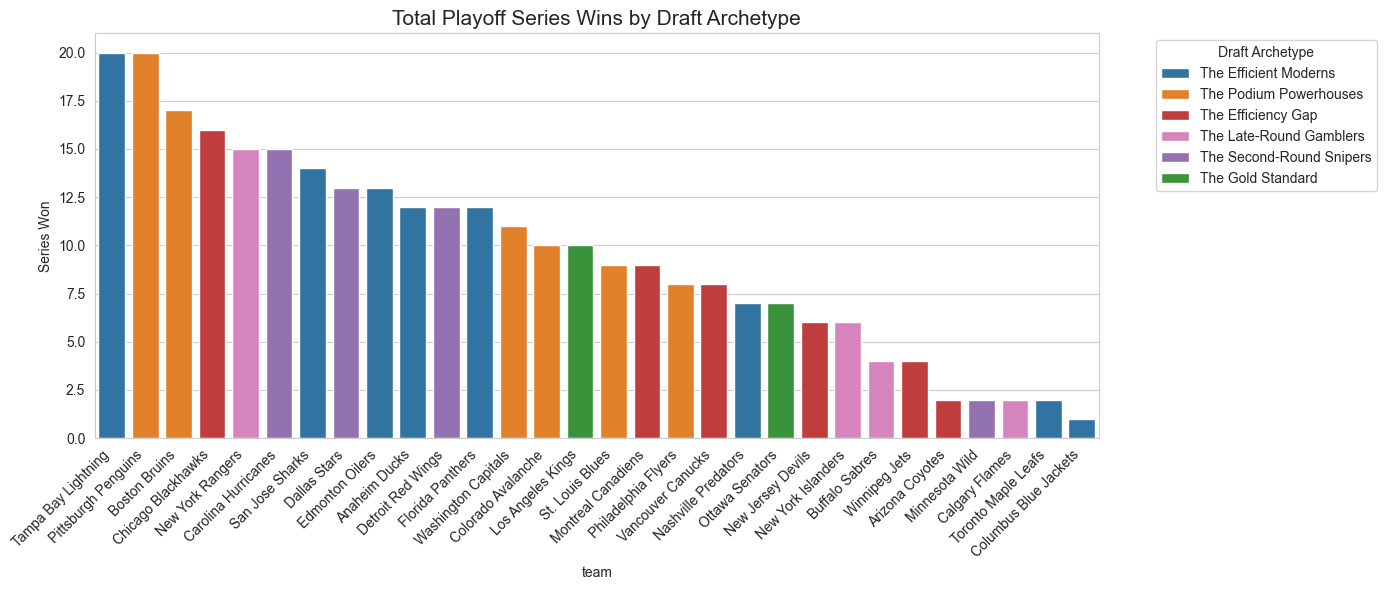

In [76]:
# Playoff Series Wins (The "Sustained Success" View)
sns.set_style("whitegrid")

# Define static color mapping for your archetypes
archetype_colors = {
    'The Gold Standard': '#2ca02c',      # Green
    'The Efficient Moderns': '#1f77b4',   # Blue
    'The Podium Powerhouses': '#ff7f0e', # Orange
    'The Second-Round Snipers': '#9467bd', # Purple
    'The Late-Round Gamblers': '#e377c2', # Pink
    'The Efficiency Gap': '#d62728'       # Red
}

plt.figure(figsize=(14, 6))
series_plot = sns.barplot(
    data=final_df.sort_values('series_wins', ascending=False),
    x='team', y='series_wins', hue='Archetype', 
    palette=archetype_colors
)

plt.title('Total Playoff Series Wins by Draft Archetype', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Series Won')
plt.legend(title='Draft Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **The Parity Paradox: 5 Archetypes, 1 Goal**

The most significant finding in the "Sustained Success" view is the **sheer diversity** at the top. In the top six teams for playoff series wins, we see **five different drafting archetypes** represented:

*   **The Podium Powerhouses:** Pittsburgh (20 wins) & Boston (17 wins)
*   **The Efficient Moderns:** Tampa Bay (20 wins)
*   **The Efficiency Gap:** Chicago (16 wins)
*   **The Late-Round Gamblers:** NY Rangers (15 wins)
*   **The Second-Round Snipers:** Carolina (15 wins)

> **The Missing Piece:** Notably absent from this elite top tier is **The Gold Standard**.

This confirms a central thesis of this investigation: **There is no "One True Way" to build a contender in the NHL.** Whether a team finds value in the late rounds, gambles on high-ceiling talent, or builds through modern efficiency, the league’s parity allows multiple philosophies to reach the summit. While "The Gold Standard" provides a high floor, the data shows it is not a prerequisite for becoming a perennial powerhouse.

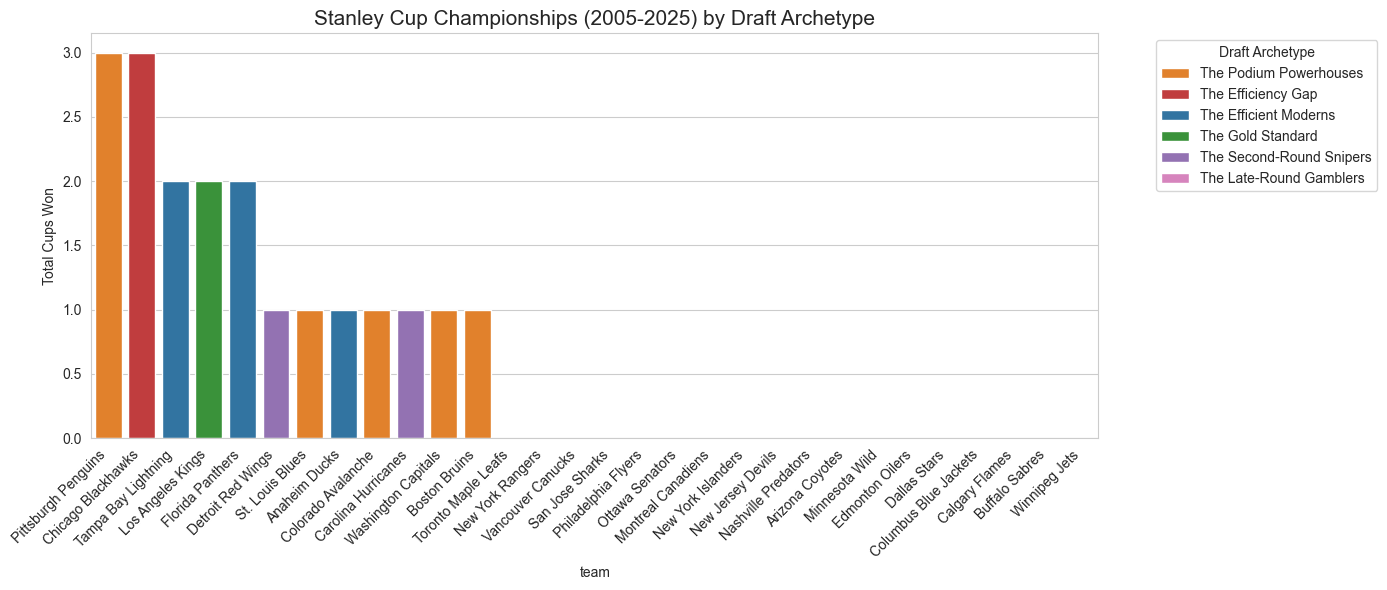

In [77]:
# Stanley Cups (The "Hardware" View)
plt.figure(figsize=(14, 6))
cup_plot = sns.barplot(
    data=final_df.sort_values('is_cup', ascending=False),
    x='team', y='is_cup', hue='Archetype', 
    palette=archetype_colors
)

plt.title('Stanley Cup Championships (2005-2025) by Draft Archetype', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Cups Won')
plt.legend(title='Draft Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **The Hardware Gap: Efficiency vs. Execution**

The Stanley Cup view introduces a "survivorship bias" that complicates the drafting narrative. While our archetypes categorize how teams *build*, this chart shows who actually *finished*.

*   **The Opportunistic Outliers:** The **Los Angeles Kings** serve as the primary case study here. Despite having fewer total playoff series wins than other powerhouses, they maximized their windows perfectly—converting a "Gold Standard" drafting foundation into two championships with clinical efficiency.
*   **The Powerhouse Consolidation:** We see heavy championship concentration in **The Podium Powerhouses** (Pittsburgh) and **The Efficiency Gap** (Chicago). This suggests that while a 7-round "efficient" draft strategy is great for depth, championships are often driven by the "Lottery Luck" of hitting on top-tier, franchise-altering talent.
*   **The Process Paradox:** Several teams in **The Efficient Moderns** and **The Second-Round Snipers** show high competitive consistency but lower "Cup conversion" rates. 

**Takeaway:** Drafting creates the "ingredients" for a contender, but the Stanley Cup is often decided by factors our draft model cannot capture: trade deadline aggression, veteran leadership, and the "hot hand" in net.

In [78]:
# Grouping results by Archetype
archetype_performance = final_df.groupby('Archetype').agg({
    'team': 'count',
    'series_wins': 'mean',
    'is_cup': 'sum'
}).rename(columns={'team': 'Team_Count', 'series_wins': 'Avg_Series_Wins', 'is_cup': 'Total_Cups'})

# Sorting by Avg Series Wins to show who is most "Sustainable"
archetype_performance.sort_values('Avg_Series_Wins', ascending=False)

,Team_Count,Avg_Series_Wins,Total_Cups
Archetype,,,
The Podium Powerhouses,6,12.500,7.0
The Second-Round Snipers,4,10.500,2.0
The Efficient Moderns,8,10.125,5.0
The Gold Standard,2,8.500,2.0
The Efficiency Gap,6,7.500,3.0
The Late-Round Gamblers,4,6.750,0.0


### **The Archetype Leaderboard: Sustained Success vs. Peak Performance**

This aggregate view reveals the true "ROI" of each drafting philosophy. By grouping the teams, the noise of individual seasons disappears, leaving us with a clear hierarchy of scouting outcomes:

*   **The Dynasty Drivers:** **The Podium Powerhouses** lead the league in both average success (**12.5 wins**) and hardware (**7 Cups**). This suggests that a strategy built around high-end picks (The "Podium") combined with veteran stability is the most proven path to a dynasty.
*   **The Modern Floor:** **The Efficient Moderns** and **The Second-Round Snipers** both boast high average series wins (**10+**), proving that "Drafting for Depth" creates a perennial playoff team that is always in the conversation, even if the Cup total isn't as high.
*   **The High-End Gamble:** Interestingly, **The Gold Standard** teams actually have fewer average wins than the "Modern" groups. This implies that "perfect" drafting across all seven rounds can sometimes lead to a "middle-of-the-pack" trap, whereas teams that hit on specific, high-impact archetypes (even with more misses) tend to climb higher.

**Final Verdict:** If you want a **guaranteed playoff spot**, follow the *Efficient Moderns*. If you want a **dynasty**, you need the *Podium Powerhouse* blend of elite lottery talent and consistent execution.

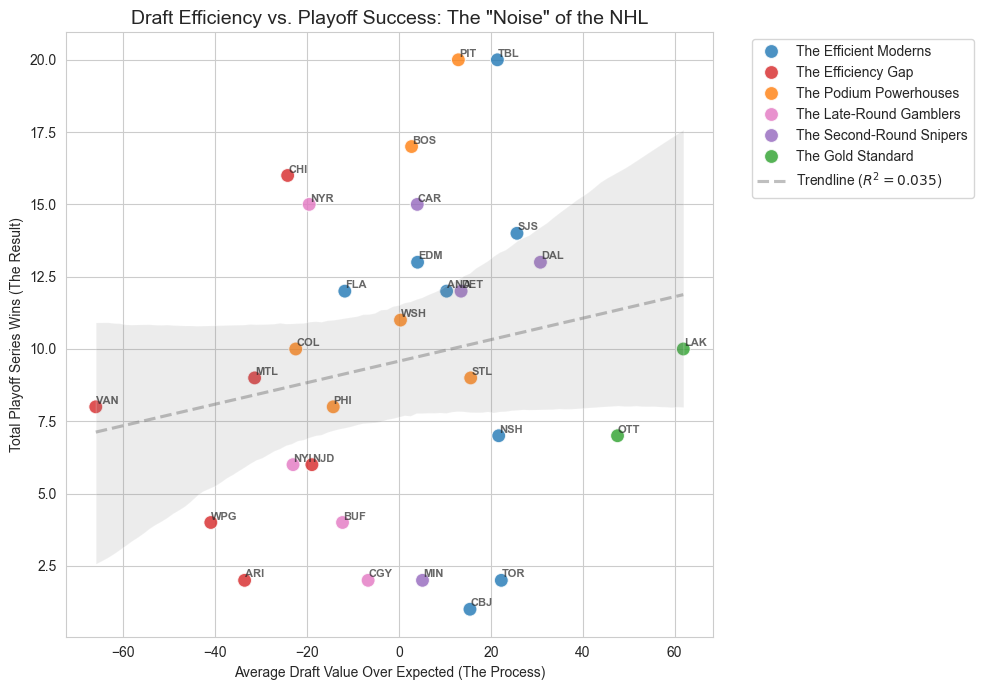

In [79]:
from scipy import stats

# 1. Prepare the data with Abbreviations
# We merge in the 'Abbr' from your perf_df and the 'avg_per_pick' from analysis_df
scatter_df = final_df.merge(analysis_df[['avg_per_pick']].reset_index(), left_on='team', right_on='team')

# Add abbreviations back for labeling (mapping from our name_map keys/values)
inv_map = {v: k for k, v in name_map.items()}
scatter_df['Abbr'] = scatter_df['team'].map(inv_map)

# 2. Calculate R-Squared for the legend
x_data = scatter_df['avg_per_pick']
y_data = scatter_df['series_wins']
slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
r_squared = r_value**2

# 3. Plotting (The "Cuter" Version)
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# The Scatter
sns.scatterplot(
    data=scatter_df,
    x='avg_per_pick', y='series_wins', 
    hue='Archetype', palette=archetype_colors,
    s=100, alpha=0.8
)

# The Regression Line
sns.regplot(
    data=scatter_df, x='avg_per_pick', y='series_wins', 
    scatter=False, color='gray', 
    line_kws={"linestyle":"--", "alpha":0.5},
    label=f'Trendline ($R^2 = {r_squared:.3f}$)'
)

# 4. Add Abbreviation Labels
for i in range(scatter_df.shape[0]):
    plt.text(
        scatter_df.avg_per_pick[i] + 0.1, 
        scatter_df.series_wins[i] + 0.1, 
        scatter_df.Abbr[i], 
        fontsize=8, alpha=0.7, weight='bold'
    )

plt.title('Draft Efficiency vs. Playoff Success: The "Noise" of the NHL', fontsize=14)
plt.xlabel('Average Draft Value Over Expected (The Process)')
plt.ylabel('Total Playoff Series Wins (The Result)')

# Place legend outside to keep the plot clean
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **The "3.5% Reality": Why Drafting Isn't Destiny**

Our regression analysis yielded an **$R^2$ of 0.035**, meaning draft efficiency accounts for only **3.5%** of the variance in playoff success. 

**What this actually tells us:**
*   **Drafting is the "Floor," not the "Ceiling":** A high-efficiency draft process (like *The Gold Standard* or *The Efficient Moderns*) keeps an organization competitive and relevant, but it does not guarantee a championship.
*   **The NHL Chaos Factor:** In a salary-cap league, parity is so high that internal drafting is easily overridden by external variables: elite goaltending, trade acquisitions, and "Winning the Lottery" (hitting on a generational #1 overall pick).
*   **Strategic Insight:** For a front office, this data suggests that drafting is a **risk-mitigation tool**. You draft well so you don't *fail*, but you trade and sign aggressively so you can *win*.

**Portfolio Conclusion:** This project successfully identified distinct scouting "Archetypes," but ultimately proved that in the modern NHL, **process and outcome are loosely coupled.**